# Multiple Linear Regression with EPL Data

In this task, you will create a model for the number of points for EPL teams, based on their goals for, goals against and goal difference.

First let's load the latest Premier League table into a `pandas` dataframe.

In [1]:
# Import required libraries
import requests as r, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Create a header that says the request is coming form a browser-like agent (this is to prevent the website blocking our request)
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36',
}
# Make an http request to get the webpage with the following url
url = "http://bbc.co.uk/sport/football/premier-league/table"
page = r.get(url, headers = headers)
if(page.status_code!=200):
    print("Stopping - couldn't get web page.")
else:
    print("Web request status code:", page.status_code)
    # read_html() will find all the tables in the webpage and put them in a list.
    tables = pd.read_html(page.content)
    # In this case, there is only one table, so the length of the list should be 1.
    print("Tables found on webpage:", len(tables))
    EPL = tables[0]
    print("Preparing dataframe of EPL table")
    EPL.insert(loc=0, value=0, column='Position')
    EPL.drop(columns=['Form, Last 6 games, Oldest first'], inplace=True)
    EPL.insert(loc=1, value='', column='Team New')
    rows = EPL.shape[0]
    for x in range(rows):
        EPL.iloc[x, 0]=x+1
        raw_name = EPL.iloc[x, 2]
        if x < 9:
            EPL.iloc[x, 1] = raw_name[1:len(raw_name)]
        elif x >=9:
            EPL.iloc[x, 1] = raw_name[2:len(raw_name)]
    EPL.drop(columns=['Team'], inplace=True)
    EPL.rename(columns={"Team New":"Team"}, inplace=True)
    EPL.rename(columns={'Drawn':"Tied"}, inplace=True)

Web request status code: 200
Tables found on webpage: 1
Preparing dataframe of EPL table


In [2]:
# Take a look at the dataframe
EPL.head()

,Position,Team,Played,Won,Tied,Lost,Goals For,Goals Against,Goal Difference,Points
0,1,Arsenal,30,20,7,3,59,22,37,67
1,2,Manchester City,29,18,6,5,59,27,32,60
2,3,Manchester United,29,14,9,6,51,40,11,51
3,4,Aston Villa,29,15,6,8,39,34,5,51
4,5,Chelsea,29,13,9,7,53,34,19,48


## Single vs Multiple Regression

We will try out two models:

A single variable model where we predict points based on solely goal difference.

A multivariable model where we predict points based on goals for and goals against.

We will then decide which is the better model.

For this exercise, we will use the `LinearRegression` library from `scikit-learn`.

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Define independent variables (X) and the dependent variable (y)
X1 = EPL[['Goal Difference']] # One independent variable
y = EPL['Points']             # Single dependent variable


# Create and train the model
model = LinearRegression()
model.fit(X1, y)

# Make predictions
EPL['predictions1'] = model.predict(X1)

# Print the coefficients and intercept
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

# Evaluate the model (e.g., using R-squared score)
r_sq = model.score(X1, y)
print(f"R-squared score: {r_sq}")

Coefficients: [0.72783159]
Intercept: 39.85
R-squared score: 0.9340093085147066


In [7]:
X2 = EPL[['Goals For', 'Goals Against']] # Now use two independent variables

model = LinearRegression()
model.fit(X2, y)
EPL['predictions2'] = model.predict(X2)

# Print the coefficients and intercept
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

# Evaluate the model (e.g., using R-squared score)
r_sq = model.score(X2, y)
print(f"R-squared score: {r_sq}")

Coefficients: [ 0.65874962 -0.80655036]
Intercept: 45.813759745717675
R-squared score: 0.9364764421337125


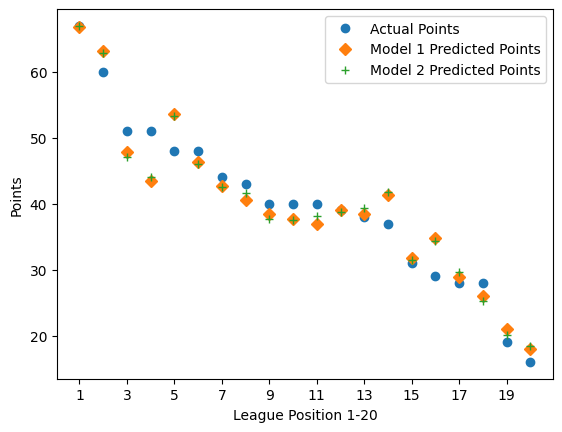

In [15]:
# Plot actual versus predicted points for both models to compare accuracy
plt.plot(EPL['Position'], EPL['Points'], 'o', label='Actual Points')
plt.plot(EPL['Position'], EPL['predictions1'], 'D', label='Model 1 Predicted Points')
plt.plot(EPL['Position'], EPL['predictions2'], '+', label='Model 2 Predicted Points')
plt.xticks(range(1, 21, 2))
plt.xlabel("League Position 1-20")
plt.ylabel("Points")
plt.legend()
plt.show()